In [14]:
import pandas as pd

def FoundFeatures(Path):
    df = pd.read_excel(Path)
    Features = set(df.columns)
    return Features


def extract_PATIENT_INFO(db):
    ids = db.pop("ID")
    morf_codificata = db.pop("morf_codificata")
    luogo_tc = db.pop("luogoTC_codificato")
    return db, ids, morf_codificata, luogo_tc


def print_binary_distribution(y, name):
    print(f"{name} size = {len(y)}")
    try:
        print(y.value_counts(dropna=False))
    except Exception:
        print(pd.Series(y).value_counts(dropna=False))


X_test = pd.read_excel("Dataset/cleaned_external.xlsx")
X_test, ids, morf_codificata, luogo_tc = extract_PATIENT_INFO(X_test)
y_test = X_test.pop("maligno")


In [15]:
X_test.head()

,BAS_MORPHOLOGICAL_VolumeIBSIRNU0,BAS_MORPHOLOGICAL_ApproximateVolumeIBSIYEKZ,BAS_MORPHOLOGICAL_voxelsCountingIBSINo,BAS_MORPHOLOGICAL_SurfaceAreaIBSIC0JK,BAS_MORPHOLOGICAL_SurfaceToVolumeRatioIBSI2PR5,BAS_MORPHOLOGICAL_CompacityIBSINo,BAS_MORPHOLOGICAL_Compactness1IBSISKGS,BAS_MORPHOLOGICAL_Compactness2IBSIBQWJ,BAS_MORPHOLOGICAL_SphericalDisproportionIBSIKRCK,BAS_MORPHOLOGICAL_SphericityIBSIQCFX,...,BAS_GLSZM_LargeZoneLowGreyLevelEmphasisIBSIYH51,BAS_GLSZM_LargeZoneHighGreyLevelEmphasisIBSIJ17V,BAS_GLSZM_GreyLevelNonUniformityIBSIJNSA,BAS_GLSZM_NormalisedGreyLevelNonUniformityIBSIY1RO,BAS_GLSZM_ZoneSizeNonUniformityIBSI4JP3,BAS_GLSZM_NormalisedZoneSizeNonUniformityIBSIVB3A,BAS_GLSZM_ZonePercentageIBSIP30P,BAS_GLSZM_GreyLevelVarianceIBSIBYLV,BAS_GLSZM_ZoneSizeVarianceIBSI3NSA,BAS_GLSZM_ZoneSizeEntropyIBSIGU8N
0,4402.191017,6966.0,6966,1781.220960,0.404621,2.471446,0.033038,0.387826,1.371264,0.729254,...,0.384264,4.428227e+07,71.725253,0.072450,356.250505,0.359849,0.142119,21.885069,4074.738072,6.107528
1,7766.972946,9328.0,9328,2544.664900,0.327626,3.052258,0.034137,0.414061,1.341669,0.745340,...,0.121850,1.333287e+07,119.676602,0.059452,748.094883,0.371632,0.215802,25.303171,1252.801376,6.362324
2,10867.636648,18583.0,18583,2898.667491,0.266725,3.749184,0.039288,0.548438,1.221680,0.818545,...,0.285594,2.967872e+07,254.792004,0.062495,1552.004170,0.380673,0.219394,22.839401,2889.939056,6.244091
3,2376.235909,2693.0,2693,1244.359945,0.523669,1.909605,0.030542,0.331431,1.445003,0.692040,...,0.040984,4.397620e+06,45.406040,0.076185,216.526846,0.363300,0.221315,16.062573,404.034894,5.858797
4,1361.982636,2478.0,2478,714.911653,0.524905,1.905106,0.040199,0.574167,1.203152,0.831150,...,0.097087,1.078606e+07,30.223881,0.075184,155.701493,0.387317,0.162228,17.364329,985.057622,5.672609


In [16]:
X_test.shape

(334, 124)

In [17]:
X_test.isna().sum().sum()

nan_per_col = X_test.isna().sum()
nan_per_col[nan_per_col > 0].sort_values(ascending=False)

X_test.isna().any(axis=1).sum()

(X_test.isna().mean() * 100).sort_values(ascending=False)

BAS_MORPHOLOGICAL_VolumeIBSIRNU0                                0.0
BAS_GLCM_SumEntropyIBSIP6QZ                                     0.0
BAS_GLCM_ClusterProminenceIBSIAE86                              0.0
BAS_GLCM_ClusterShadeIBSI7NFM                                   0.0
BAS_GLCM_ClusterTendencyIBSIDG8W                                0.0
                                                               ... 
BAS_INTENSITYBASED_TotalLesionGlycolysisHUIBSINo                0.0
BAS_INTENSITYBASED_RootMeanSquareHUIBSI5ZWQ                     0.0
BAS_INTENSITYBASED_EnergyHUIBSIN8CA                             0.0
BAS_INTENSITYBASED_QuartileCoefficientOfDispersionHUIBSI9S40    0.0
BAS_GLSZM_ZoneSizeEntropyIBSIGU8N                               0.0
Length: 124, dtype: float64

In [18]:
y_test.head()

0    0
1    0
2    0
3    0
4    0
Name: maligno, dtype: int64

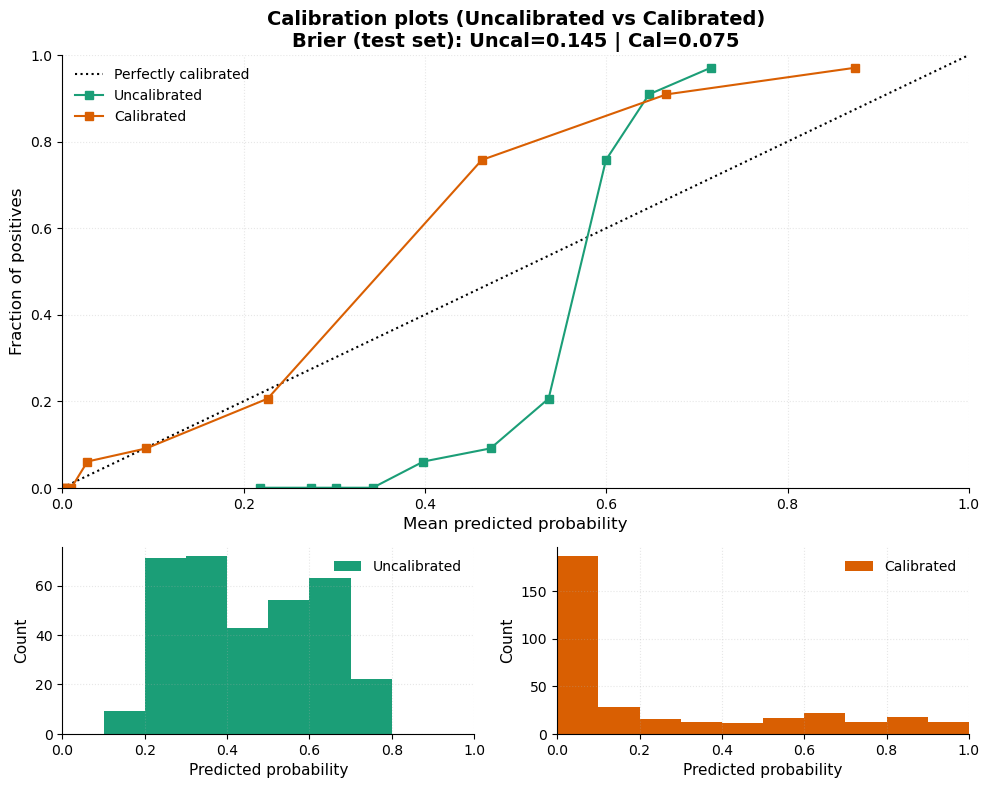

In [19]:
from sklearn.calibration import CalibrationDisplay
from matplotlib.gridspec import GridSpec
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import joblib

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().resolve().parent))  

PREFIX = "deploy_model"
fitted_pipeline = joblib.load(f"../CenterBologna/Elements/Boruta_RusBoost/{PREFIX}Boruta_RusBoostFitted_pipeline.pkl")
calibrated_pipeline = joblib.load("../CenterBologna/Elements/Boruta_RusBoost/deploy_modelCalibrated_model.pkl")



clf_list = [
    (fitted_pipeline, "Uncalibrated"),
    (calibrated_pipeline, "Calibrated"),
]

fig = plt.figure(figsize=(10, 10))
gs = GridSpec(4, 2)
colors = plt.get_cmap("Dark2")
ax_calibration_curve = fig.add_subplot(gs[:2, :2])
calibration_displays = {}
brier_scores = {}
for i, (clf, name) in enumerate(clf_list):
    y_prob = clf.predict_proba(X_test)[:, 1]
    brier_scores[name] = brier_score_loss(y_test, y_prob)

    display = CalibrationDisplay.from_predictions(
         y_test,
        y_prob,
        n_bins=10,
        strategy="quantile",
        name=name,
        ax=ax_calibration_curve,
        color=colors(i),
    )
    calibration_displays[name] = display

# Mirror DCA style
ax_calibration_curve.set_xlim(0, 1)
ax_calibration_curve.set_ylim(0, 1)
ax_calibration_curve.set_xlabel("Mean predicted probability", fontsize=12)
ax_calibration_curve.set_ylabel("Fraction of positives", fontsize=12)
ax_calibration_curve.set_title(
    "Calibration plots (Uncalibrated vs Calibrated)\n"
    f"Brier (test set): Uncal={round(brier_scores['Uncalibrated'], 3)} | Cal={round(brier_scores['Calibrated'], 3)}",
    fontsize=14,
    fontweight="bold",
)
ax_calibration_curve.legend(frameon=False, fontsize=10)
ax_calibration_curve.grid(alpha=0.3, ls=":")
ax_calibration_curve.spines['top'].set_visible(False)
ax_calibration_curve.spines['right'].set_visible(False)
grid_positions = [(2, 0), (2, 1)]
for i, (_, name) in enumerate(clf_list):
    row, col = grid_positions[i]
    ax = fig.add_subplot(gs[row, col])
    ax.hist(
        calibration_displays[name].y_prob,
        range=(0, 1),
        bins=10,
        label=name,
        color=colors(i),
    )
    ax.set_xlim(0, 1)
    ax.set_xlabel("Predicted probability", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.legend(frameon=False, fontsize=10)
    ax.grid(alpha=0.3, ls=":")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

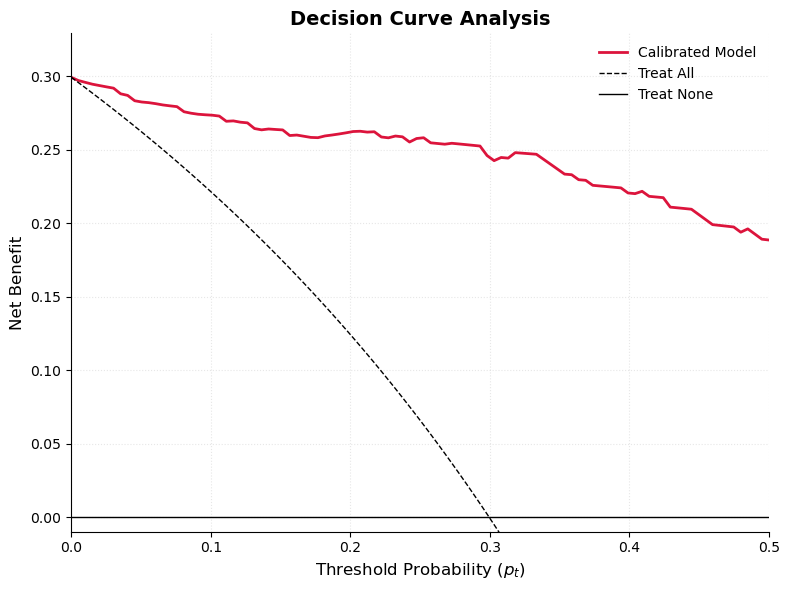

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def decision_curve_binary(y_true, y_prob, thresholds):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    n = len(y_true)
    prevalence = np.mean(y_true)

    net_benefit_model = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tp = np.sum((y_pred == 1) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        
        # Formula del Net Benefit 
        nb_model = (tp / n) - (fp / n) * (t / (1 - t))
        net_benefit_model.append(nb_model)

    # NB per trattare tutti: Beneficio = Prevalenza, Danno = (1 - Prevalenza)
    net_benefit_all = prevalence - (1 - prevalence) * (thresholds / (1 - thresholds))
    
    return {
        "thresholds": thresholds,
        "model": np.array(net_benefit_model),
        "treat_all": net_benefit_all,
        "treat_none": np.zeros_like(thresholds),
    }

thresholds = np.linspace(0.00, 0.50, 100)
cal_probs= calibrated_pipeline.predict_proba(X_test)[:, 1]
dca = decision_curve_binary(y_test, cal_probs, thresholds)

plt.figure(figsize=(8, 6))

plt.plot(dca["thresholds"], dca["model"], color='crimson', lw=2, label="Calibrated Model")

# Linea Treat All 
plt.plot(dca["thresholds"], dca["treat_all"], color='black', linestyle='--', lw=1, label="Treat All")

# Linea Treat None (asse orizzontale a zero) 
plt.plot(dca["thresholds"], dca["treat_none"], color='black', lw=1, label="Treat None")

plt.xlim(0, 0.50)
plt.ylim(-0.01, max(dca["model"].max(), dca["treat_all"].max()) * 1.1)

plt.xlabel("Threshold Probability ($p_t$)", fontsize=12)
plt.ylabel("Net Benefit", fontsize=12)
plt.title("Decision Curve Analysis", fontsize=14, fontweight='bold')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(frameon=False, fontsize=10)
plt.grid(alpha=0.3, ls=':')
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    auc
)

cal_probs = calibrated_pipeline.predict_proba(X_test)[:, 1]

# AUC-ROC
auc_roc = roc_auc_score(y_test, cal_probs)

# PR AUC (Average Precision)
pr_auc = average_precision_score(y_test, cal_probs)

print(f"AUC-ROC: {auc_roc:.4f}")
print(f"PR AUC: {pr_auc:.4f}")

AUC-ROC: 0.9692
PR AUC: 0.9326


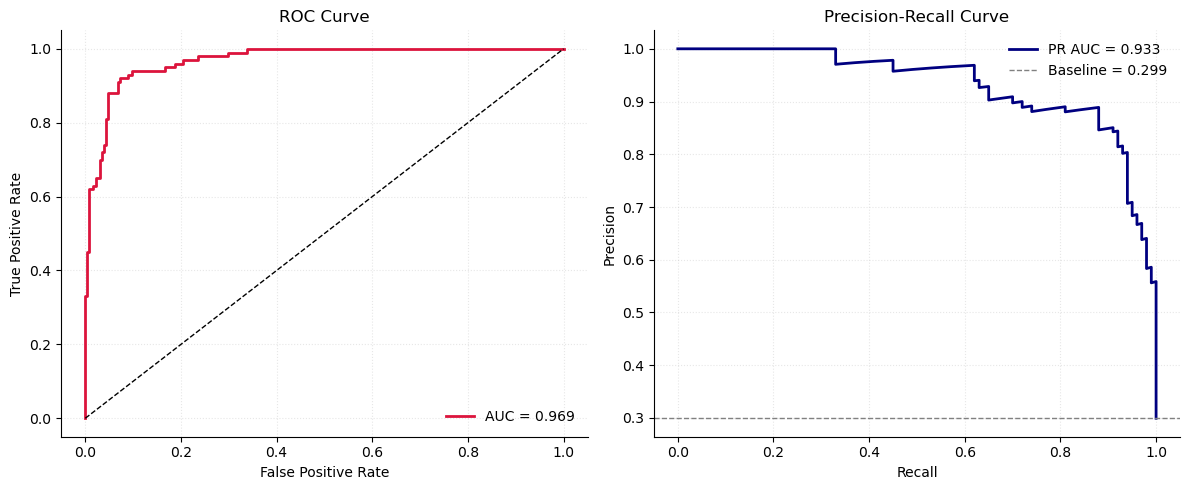

AUC-ROC : 0.9692
PR AUC  : 0.9326


In [22]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

cal_probs = calibrated_pipeline.predict_proba(X_test)[:, 1]

# ROC
fpr, tpr, _ = roc_curve(y_test, cal_probs)
auc_roc = roc_auc_score(y_test, cal_probs)

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, cal_probs)
pr_auc = average_precision_score(y_test, cal_probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(
    fpr,
    tpr,
    color='crimson',
    lw=2,
    label=f'AUC = {auc_roc:.3f}'
)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1)

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")

axes[0].legend(frameon=False)
axes[0].grid(alpha=0.3, ls=':')

# Precision-Recall Curve
axes[1].plot(
    recall,
    precision,
    color='navy',
    lw=2,
    label=f'PR AUC = {pr_auc:.3f}'
)

# baseline = prevalenza positiva
baseline = np.mean(y_test)

axes[1].axhline(
    baseline,
    color='gray',
    linestyle='--',
    lw=1,
    label=f'Baseline = {baseline:.3f}'
)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")

axes[1].legend(frameon=False)
axes[1].grid(alpha=0.3, ls=':')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"AUC-ROC : {auc_roc:.4f}")
print(f"PR AUC  : {pr_auc:.4f}")

In [23]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from scipy.special import logit  
eps = 1e-15

import statsmodels.api as sm


def compute_slope_intercept(y_true, y_prob):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    logit_p = logit(y_prob) 
    #logit_p = np.log(y_prob / (1 - y_prob))
    X = sm.add_constant(logit_p)
    model = sm.Logit(y_true, X).fit(disp=0)
    return model.params[0], model.params[1]  # intercept, slope


# Stratified bootstrap
def stratified_bootstrap(y_true, rng):
    y_true = np.array(y_true)
    idx0 = np.where(y_true == 0)[0]
    idx1 = np.where(y_true == 1)[0]
    if len(idx0) == 0 or len(idx1) == 0:
        raise ValueError(f"Classe mancante: {len(idx0)} negativi, {len(idx1)} positivi")
    sample0 = rng.choice(idx0, size=len(idx0), replace=True)
    sample1 = rng.choice(idx1, size=len(idx1), replace=True)
    return np.concatenate([sample0, sample1])

def bootstrap_calibration(y_true, y_prob, n_boot=5000, seed=42):
    rng = np.random.default_rng(seed)
    intercepts, slopes = [], []
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    for _ in range(n_boot):
        idx = stratified_bootstrap(y_true, rng)
        # Per IC
        i, s = compute_slope_intercept(y_true[idx], y_prob[idx])
        if not (np.isnan(i) or np.isnan(s)):
            intercepts.append(i)
            slopes.append(s)

    intercepts = np.array(intercepts)
    slopes     = np.array(slopes)

    i_hat, s_hat = compute_slope_intercept(y_true, y_prob)

    return {
        "intercept":           i_hat,
        "slope":               s_hat,
        "ci_intercept":        np.percentile(intercepts, [2.5, 97.5]),
        "ci_slope":            np.percentile(slopes,     [2.5, 97.5]),
        "boot_intercept_mean": np.mean(intercepts),
        "boot_slope_mean":     np.mean(slopes),
        "n_boot_valid":        len(intercepts),
        "n_boot_requested":    n_boot,
        "seed":                seed,
    }


results = bootstrap_calibration(y_test, cal_probs, n_boot=5000)

results

{'intercept': 1.0682696428469132,
 'slope': 1.4774351816004747,
 'ci_intercept': array([0.70839403, 1.64933596]),
 'ci_slope': array([1.18005182, 2.04118087]),
 'boot_intercept_mean': 1.1062657919348624,
 'boot_slope_mean': 1.5274385656810414,
 'n_boot_valid': 5000,
 'n_boot_requested': 5000,
 'seed': 42}

In [24]:
mask = cal_probs <= 0.3
y_test_sub = y_test[mask]
cal_probs_sub = cal_probs[mask]

results = bootstrap_calibration(y_test_sub, cal_probs_sub, n_boot=5000)
print(results)

{'intercept': 0.5644094069359875, 'slope': 1.2396041471825576, 'ci_intercept': array([-0.35930153,  2.77893901]), 'ci_slope': array([0.79715605, 2.69816359]), 'boot_intercept_mean': 0.7778281795847052, 'boot_slope_mean': 1.3876220239788382, 'n_boot_valid': 5000, 'n_boot_requested': 5000, 'seed': 42}


Subgroup Sample Size    : 230 / 334
N Eventi                : 12
Overall O/E Ratio       : 1.089 (95% CI: 0.562 – 1.903)
Subgroup ICI (Integrated Calibration Index) : 0.0189
Calibration Intercept   : 0.564 (95% CI: -0.359 to 2.779)
Calibration Slope       : 1.240 (95% CI: 0.797 to 2.698)
-----------------------------------------------------------------
Bin Range   N  Observed  Expected  O/E Ratio
0.00–0.10 187         3      2.94      1.019
0.10–0.20  28         3      4.34      0.692
0.20–0.30  15         6      3.74      1.605


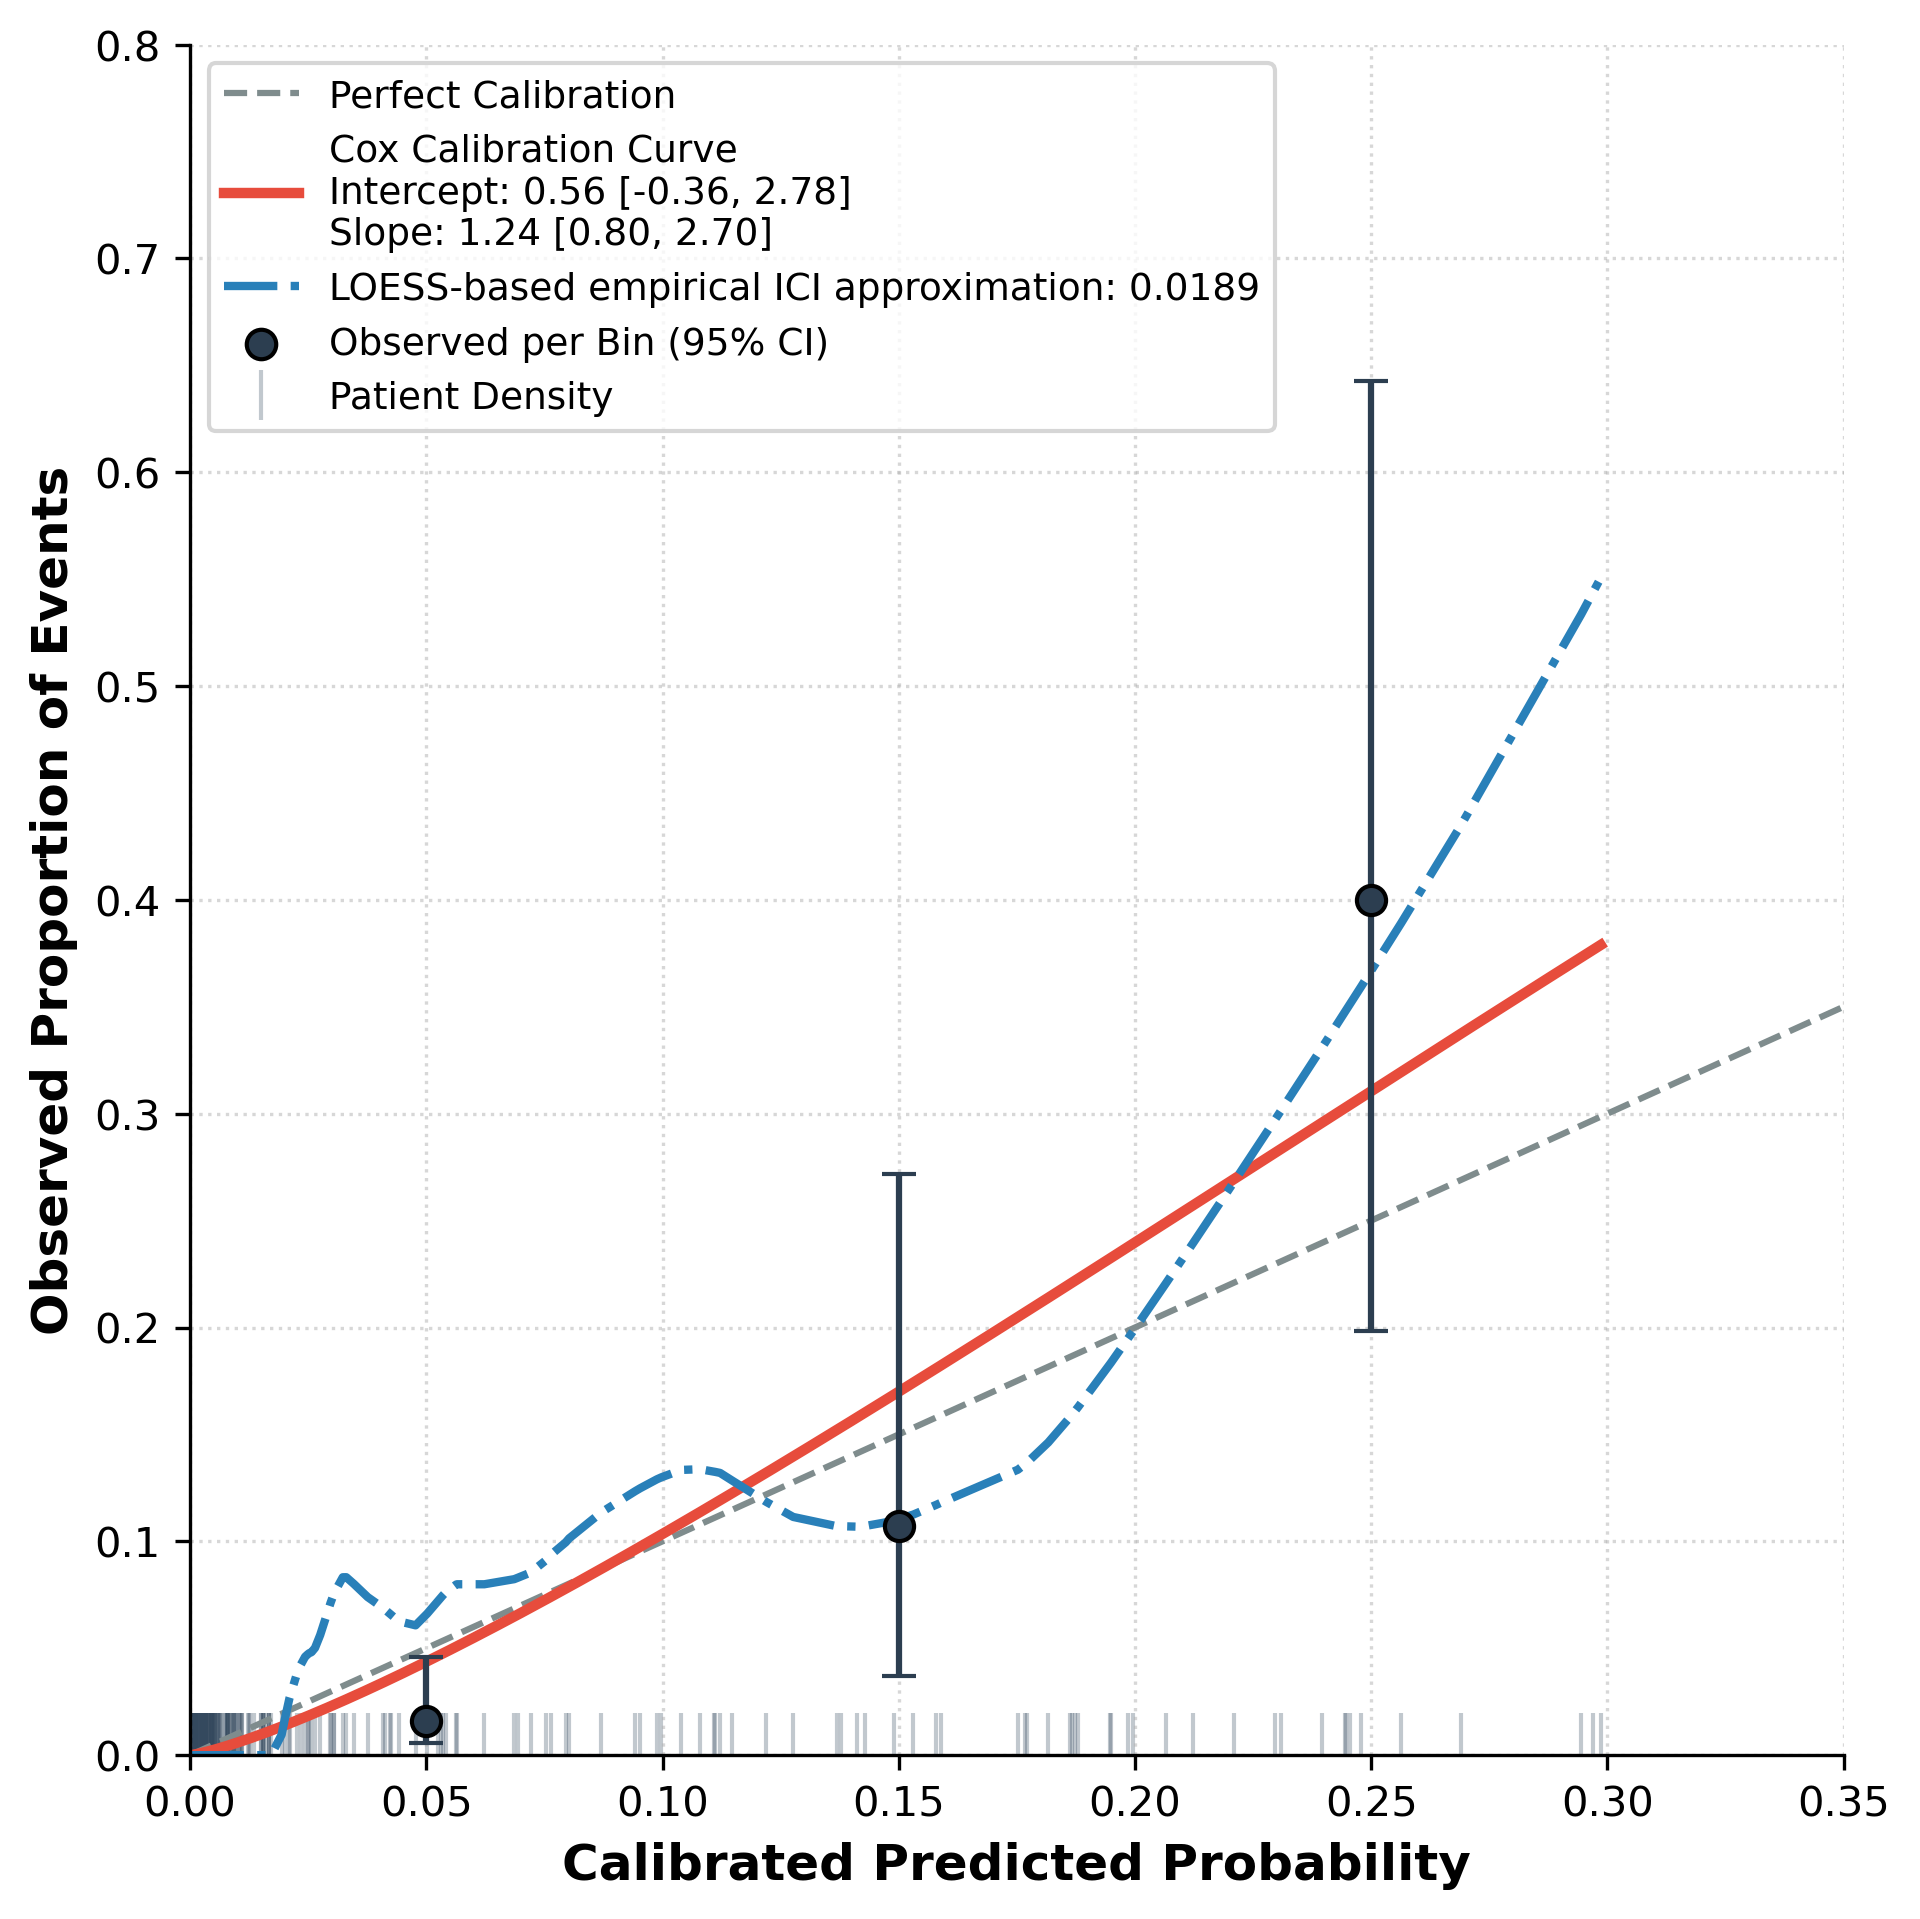

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logit
import statsmodels.api as sm
import warnings


def subgroup_pipeline_analysis(y_true, cal_probs, threshold=0.3, n_bins=3, boot_results=None):

    y_true = np.asarray(y_true).astype(int)
    cal_probs = np.asarray(cal_probs).astype(float)

    mask = cal_probs <= threshold
    y_sub = y_true[mask]
    p_sub = cal_probs[mask]

    n_sub = len(y_sub)
    if n_sub == 0:
        raise ValueError(f"Nessun paziente nella fascia <= {threshold}")

    if np.std(p_sub) < 1e-6:
        raise ValueError("Probabilità troppo concentrate prima del logit")

    observed_total = int(y_sub.sum())
    expected_total = float(p_sub.sum())

    # ── 1. O/E VIA BYAR (Breslow & Day)
    # Technical Briefing 3 Published March 2008 - Reprinted April 2010
    oe_ratio = observed_total / expected_total if expected_total > 0 else np.nan
    if observed_total > 0 and expected_total > 0:
        c = observed_total
        lower_inner = 1 - 1/(9*c) - 1.96/(3*np.sqrt(c))
        upper_inner = 1 - 1/(9*(c+1)) + 1.96/(3*np.sqrt(c+1))
        lower_o = c * (lower_inner**3)
        upper_o = (c + 1) * (upper_inner**3)
        oe_lower = lower_o / expected_total
        oe_upper = upper_o / expected_total
    else:
        oe_lower, oe_upper = np.nan, np.nan

    # ── 2. COX via sm.Logit — solo per α e β
    epsilon = 1e-15
    p_sub_clipped = np.clip(p_sub, epsilon, 1 - epsilon)
    logit_p_sub = logit(p_sub_clipped)

    if np.std(logit_p_sub) < 1e-6:
        raise ValueError("Varianza logit troppo bassa: probabilità troppo concentrate")

    X_cox = sm.add_constant(logit_p_sub)
    logit_model = sm.Logit(y_sub, X_cox).fit(disp=0)

    if not logit_model.mle_retvals['converged']:
        warnings.warn("Cox calibration: modello non convergente")

    intercept_alpha = logit_model.params[0]
    slope_beta = logit_model.params[1]

    # Curva Cox per il plot
    p_plot = np.linspace(p_sub.min(), p_sub.max(), 300)
    logit_p_plot = logit(np.clip(p_plot, epsilon, 1 - epsilon))
    X_plot = sm.add_constant(logit_p_plot)
    y_smoothed_plot = logit_model.predict(X_plot)

    # ── 3. LOESS — ICI (Austin & Steyerberg 2019)
    lowess_fn = sm.nonparametric.lowess

    loess_sorted = lowess_fn(
        endog=y_sub,
        exog=p_sub,
        frac=0.3,
        it=0,
        return_sorted=True
    )
    # prob predette
    x_smooth = loess_sorted[:, 0]
    # stima E[Y/X]
    y_smooth = loess_sorted[:, 1]

    # Check stabilità LOESS
    if np.std(y_smooth) < 1e-6:
        warnings.warn(
            "LOESS ha prodotto una curva quasi piatta — "
            "possibile insufficienza di eventi o assenza di segnale di calibrazione"
        )
        ici = np.nan
        loess_available = False

    else:
        # funzione di calibrazione m(p); stima il corrispondnete creando una mappa punto per punto
        m_hat = np.interp(p_sub, x_smooth, y_smooth)

        # ICI classico (LOESS-based approximation)
        ici = np.mean(np.abs(m_hat - p_sub))

        loess_available = True
        # ── 4. BIN ANALYSIS
        bins = np.linspace(0.0, threshold, n_bins + 1)
        bin_results = []

    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        bin_mask = (p_sub >= lo) & (p_sub <= hi) if i == n_bins - 1 else (p_sub >= lo) & (p_sub < hi)

        n_bin = bin_mask.sum()
        obs_bin = y_sub[bin_mask].sum()
        exp_bin = p_sub[bin_mask].sum()
        oe_bin = obs_bin / exp_bin if exp_bin > 0 else np.nan

        bin_results.append({
            'Bin Range': f"{lo:.2f}–{hi:.2f}",
            'N': int(n_bin),
            'Observed': int(obs_bin),
            'Expected': round(exp_bin, 2),
            'O/E Ratio': round(oe_bin, 3) if not np.isnan(oe_bin) else 'n/a'
        })

    df_bins = pd.DataFrame(bin_results)

    ici_str = f"{ici:.4f}" if not np.isnan(ici) else "n/a (eventi insufficienti)"
    n_eventi = int(y_sub.sum())
    print("="*65)
    print(f"Subgroup Sample Size    : {n_sub} / {len(y_true)}")
    print(f"N Eventi                : {n_eventi}")
    print(f"Overall O/E Ratio       : {oe_ratio:.3f} (95% CI: {oe_lower:.3f} – {oe_upper:.3f})")
    print(f"Subgroup ICI (Integrated Calibration Index) : {ici_str}")
    if boot_results:
        print(f"Calibration Intercept   : {intercept_alpha:.3f} (95% CI: {boot_results['ci_intercept'][0]:.3f} to {boot_results['ci_intercept'][1]:.3f})")
        print(f"Calibration Slope       : {slope_beta:.3f} (95% CI: {boot_results['ci_slope'][0]:.3f} to {boot_results['ci_slope'][1]:.3f})")
    else:
        print(f"Calibration Intercept   : {intercept_alpha:.3f} (Target: 0.000)")
        print(f"Calibration Slope       : {slope_beta:.3f} (Target: 1.000)")
    print("-"*65)
    print(df_bins.to_string(index=False))
    print("="*65)

    # ── 6. PLOT
    fig, ax = plt.subplots(figsize=(6.5, 6.5), dpi=300)

    # Diagonale perfetta
    ax.plot([0, threshold + 0.05], [0, threshold + 0.05],
            linestyle='--', color='#7f8c8d', lw=1.5, label='Perfect Calibration')

    # Curva Cox
    if boot_results:
        curve_label = (
            f'Cox Calibration Curve\n'
            f'Intercept: {intercept_alpha:.2f} [{boot_results["ci_intercept"][0]:.2f}, {boot_results["ci_intercept"][1]:.2f}]\n'
            f'Slope: {slope_beta:.2f} [{boot_results["ci_slope"][0]:.2f}, {boot_results["ci_slope"][1]:.2f}]'
        )
    else:
        curve_label = (
            f'Empirical (Cox Logit Model)\n'
            f'Intercept: {intercept_alpha:.2f}\n'
            f'Slope: {slope_beta:.2f}'
        )
    ax.plot(p_plot, y_smoothed_plot, color='#e74c3c', lw=2.5, label=curve_label)

    # Curva Loess
    if loess_available:
        ax.plot(x_smooth, y_smooth,
                color='#2980b9', lw=2, linestyle='-.',
                label=f'LOESS-based empirical ICI approximation: {ici:.4f}')

    # Bin points con Wilson CI
    for i in range(len(df_bins)):
        row = df_bins.iloc[i]
        n = row['N']
        if n == 0:
            print("EMPTY bin")
            continue

        p_obs = row['Observed'] / n
        intervallo_testo = row['Bin Range'].split('–')
        mid = (float(intervallo_testo[0]) + float(intervallo_testo[1])) / 2

        # Wilson Score CI (Newcombe Method 3)
        z = 1.96
        p = p_obs
        q = 1 - p
        termine_base = 2 * n * p + z**2
        radice = z * np.sqrt(z**2 + 4 * n * p * q)
        denominatore_completo = 2 * (n + z**2)
        limite_inf = (termine_base - radice) / denominatore_completo
        limite_sup = (termine_base + radice) / denominatore_completo
        y_err_lower = max(0, p - limite_inf)
        y_err_upper = min(1, limite_sup - p)

        ax.errorbar(mid, p_obs,
                    yerr=np.array([[y_err_lower], [y_err_upper]]),
                    fmt='o', color='#2c3e50',
                    markerfacecolor='#2c3e50', markeredgecolor='black',
                    markersize=7, capsize=4, elinewidth=1.5, zorder=3)

    ax.scatter([], [], color='#2c3e50', edgecolors='black', s=50,
               label='Observed per Bin (95% CI)')
    ax.plot(p_sub, np.zeros_like(p_sub) + 0.008, '|',
            color='#34495e', alpha=0.3, markersize=12,
            label='Patient Density', zorder=1)

    ax.set_xlim(0, threshold + 0.05)
    ax.set_ylim(0, 0.80)
    ax.set_xlabel('Calibrated Predicted Probability', fontsize=12, fontweight='bold')
    ax.set_ylabel('Observed Proportion of Events', fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', frameon=True, fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig("images/screening_tool.png")

    plt.show()

    return df_bins


df_results = subgroup_pipeline_analysis(y_test, cal_probs, threshold=0.3, boot_results=results)